<img src="../code/Resources/cropped-SummerWorkshop_Header.png"> 

<h1 align="center">Workshop 2: Tutorial on neuronal decoding and behavior</h1> 
<h3 align="center">Summer Workshop on the Dynamic Brain</h3> 
<h3 align="center">Thursday, August 26th, 2025</h3> 
<h4 align="center">Day 2</h4>

# 0.0 Neural Coding 

Neural coding describes how neurons represent information about the world. Coding can be studied by asking whether external or internal events lead to changes in neural activity (**encoding**), or by asking whether different types of information can be read out from neural activity (**decoding**). In this workshop we will focus on this later problem. Specifically, we will try to read out information about stiumus identity from neurons recorded during the Dynamic Routing Task.

### 0.1 The dyanamic routing task

Recall the task from before lunch! There are 4 stimuli, two auditory and two visual, plus catch trials. Add more relevent details here.

### 0.2 Our questions

1. Can we tell which stimulus the mouse got, just from spikes?
2. Does the whole population do better than one neuron?
3. When the decoder is wrong, why is it wrong?

That last one is where context sneaks in.

# 1.0 Setup

To Python, we first need packages Lets start with some you are familiar with. Numpy, Pandas, and matplotlib should be favorites of yours by now. In addition, lets grab your new friend pynwb so that we can actually look some data!

First the imports. We add seaborn and set the talk context so fonts are readable on a projector.

In [7]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# pynwb reads the Neuropixels session file (NWB format)
import pynwb

from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

sns.set_context('talk')          # readable on a projector
pd.set_option('display.max_columns', None)

### 1.1 An example session.

We will all use the same one to get started.

For today we load the NWB from disk. The CodeOcean capsule path is kept below, commented out, for when we move to the cluster.

In [10]:
session_id = '742903_2024-10-22'

# --- LOCAL (use this for now) ---
nwb_path = 'C:/Users/User/Documents/GitHub/DR_project/742903_2024-10-22.nwb'

# --- CODEOCEAN CAPSULE (uncomment later, comment the local line above) ---
# nwb_path = '/root/capsule/data/%s/%s.nwb' % (session_id, session_id)

session = pynwb.NWBHDF5IO(nwb_path, mode='r').read()
print('loaded session %s' % session_id)

loaded session 742903_2024-10-22


Take a look at the whole session object. Click the triangles to explore what is inside.

In [12]:
session

Data type,float64
Shape,"(463723,)"
Array size,3.54 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),3709784
Compressed size (bytes),3709784
Compression ratio,1.0
Data type,float64
Shape,"(463716,)"


### 1.2 The trials table

Remember that the trial table lists all the per-trial event data.

In [14]:
trials = session.trials.to_dataframe()
print('this session has %d trials' % len(trials))
trials.head()

this session has 538 trials


,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2519.80321,2525.30780,2519.80321,2521.27107,2521.31188,2521.81188,2521.38786,2522.30530,2521.83822,2521.82993,2521.85567,2522.33292,2525.335440,sound1,0,aud,0,0.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
1,2525.44123,2530.94584,2525.44123,2526.90917,2526.94985,2527.44985,2527.02589,2527.94336,2527.12598,2527.11877,2527.14350,2527.97097,2530.973490,sound1,0,aud,1,1.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
2,2536.26697,2541.77160,2536.26697,2537.73488,2537.77573,2538.27573,2537.85162,2538.76911,2537.96839,2537.95773,2537.98592,2538.79673,2541.799250,sound1,0,aud,2,2.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
3,2542.27204,2547.77662,2542.27204,2543.73989,2543.78094,2544.28094,2543.85669,2544.77445,2543.97345,2543.96458,2543.99087,2544.80177,2547.804292,sound1,0,aud,3,3.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
4,2551.89673,2557.40138,2551.89673,2553.36467,2553.40561,2553.90561,2553.48137,2554.39889,2553.58150,2553.56528,2553.59906,2554.42650,2557.429030,sound1,0,aud,4,4.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False


### 1.3 The units table

Just as the trials table contains information about each trial, the "units" table contains information about each unit!. Lets take a look.

In [16]:
units_table = session.units.to_dataframe()
print('this session has %d units before quality control' % len(units_table))
units_table.head()

this session has 4446 units before quality control


,activity_drift,amplitude,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,ccf_ap,ccf_dv,ccf_ml,channels,cluster_id,d_prime,decoder_label,decoder_probability,default_qc,device_name,drift_mad,drift_ptp,drift_std,electrode_group_name,exp_decay,firing_range,firing_rate,half_width,is_not_drift,isi_violations_count,isi_violations_ratio,isolation_distance,l_ratio,location,nn_hit_rate,nn_miss_rate,num_negative_peaks,num_positive_peaks,num_spikes,peak_channel,peak_electrode,peak_to_valley,peak_trough_ratio,peak_waveform_index,presence_ratio,recovery_slope,repolarization_slope,rp_contamination,rp_violations,silhouette,sliding_rp_violation,snr,spike_amplitudes,spread,structure,sync_spike_2,sync_spike_4,sync_spike_8,unit_id,velocity_above,velocity_below,spike_times,obs_intervals,electrodes,electrode_group,waveform_mean,waveform_sd
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.040825,295.738655,0.000024,0.119623,0.091381,236.340000,4450.0,4400.0,4950.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",0,8.460060,sua,0.76,True,20097906812,0.646459,10.051738,1.746884,probeA,0.036991,3.8,4.891656,0.000160,True,1.0,0.001804,92.271246,0.008869,LSr,0.893762,0.001312,1,1,37776.0,0,0,0.000507,-0.281446,0,1.000000,-119515.135360,1.402202e+06,0.002709,1.0,0.209374,0.010,16.533775,"[-121.67999, -107.64, -142.73999, -109.979996,...",40.0,LSr,0.036108,0.000000,0.0,742903_2024-10-22_A-0,242.707518,NaN,"[20.28927901589777, 20.311845609610423, 20.462...","[[20.22514588989608, 7742.738080300452]]",location ...,probeA pynwb.ecephys.ElectrodeGroup at 0x20061...,"[[-2.8828790187835693, -1.750319004058838, -1....","[[15.012916564941406, 16.09957504272461, 13.74..."
1,0.039527,88.367762,0.002602,0.325891,0.232566,60.839996,4450.0,4400.0,4950.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",1,1.973730,mua,0.87,False,20097906812,NaN,NaN,NaN,probeA,0.017509,0.4,0.113434,0.000217,True,1.0,3.354522,43.712372,2.506822,LSr,0.214425,0.021882,1,1,876.0,1,1,0.000550,-0.435878,1,0.992188,-49092.995591,2.994365e+05,0.000000,0.0,0.025452,NaN,4.447247,"[-84.24, -126.35999, -114.659996, -133.37999, ...",80.0,LSr,0.028539,0.000000,0.0,742903_2024-10-22_A-1,480.240180,NaN,"[22.243439365091692, 24.726864669927423, 26.76...","[[20.22514588989608, 7742.738080300452]]",location ...,probeA pynwb.ecephys.ElectrodeGroup at 0x20061...,"[[-1.2355196475982666, -0.3322800099849701, -1...","[[16.898168563842773, 17.95831298828125, 13.93..."
2,0.228825,78.511684,0.000050,0.237714,0.101337,53.820000,4400.0,4400.0,4950.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",2,2.796198,mua,0.54,False,20097906812,1.105313,12.480831,2.101816,probeA,0.018652,6.4,5.526551,0.000253,False,45.0,0.063595,58.373226,1.475664,LSr,0.329873,0.022277,1,1,42679.0,2,2,0.000553,-0.457594,2,1.000000,-42487.653905,2.601561e+05,0.036711,17.0,0.024314,0.035,5.188625,"[-58.499996, -58.499996, -77.21999, -72.54, -4...",100.0,LSr,0.033670,0.000117,0.0,742903_2024-10-22_A-2,NaN,NaN,"[20.403111981228214, 20.608577983657746, 21.07...","[[20.22514588989608, 7742.738080300452]]",location ...,probeA pynwb.ecephys.ElectrodeGroup at 0x20061...,"[[-0.5241601467132568, -0.5943599939346313, -1...","[[14.711466789245605, 16.18790626525879, 13.58..."
3,0.054993,100.098114,NaN,NaN,NaN,72.540000,4400.0,4400.0,4950.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",3,3.496054,mua,0.51,False,20097906812,NaN,NaN,NaN,probeA,0.025959,0.2,0.053998,0.000173,True,0.0,0.000000,48.755916,2.557953,LSr,0.192254,0.015131,1,1,417.0,2,2,0.000493,-0.376650,2,0.898438,-51082.621160,3.705844e+05,0.000000,0.0,0.034633,NaN,6.982127,"[-74.88, -95.939995, -67.86, -95.939995, -98.2...",100.0,LSr,0.023981,0.000000,0.0,742903_2024-10-22_A-3,720.005846,NaN,"[33.33537017340589, 47.896756432219036, 48.233...","[[20.22514588989608, 7742.738080300452]]",location ...,probeA pynwb.ecephys.ElectrodeGroup at 0x20061...,"[[0.44892096519470215, 0.6228775978088379, -0....","[[14.37304973602295, 15.364265441894531, 12.62..."
4,0.095975,152.652222,0.000119,0.311789,0.13861

<h3> How many units are in the units table?? </h3>

In [18]:
print('number of units in the table: %d' % len(units_table))

number of units in the table: 4446


### 1.4 Unit QC

Thats a lot of units. But do we trust them all?

The truth is, one of the biggest challenges with ephy analysis sorting units and figuring out which are safe to use. Neuropixels, by virtue of having many contacts near eachother, make it possible to record many units simultaniously. This is great, but it creates an additional challenge of knowing which units are "good" for analysis. Because large recordings are almost always sorted algorithmically, selecting good units is particularly important because no human has manually identified which units are safe for further analysis.

The units table contains many unit QC metrics. Typically, rather than just blindly trusting every output of the automated sorting, we typically impose some constraints on the data. Here are a few examples of useful ones:

+ isi_violations_ratio: what fraction of spikes happen closer together than should be possible for a neuron. If this is too high, its a sign of eather non-neuronal noise or more than one neuron getting merged into a unit.
+ amplitude_cutoff: neurons have a maximum expected spike size. If a sorted unit's waveform is too large, its a sign that it isn't really a neruon.
+ presence_ratio: recordings are not 100% static. If the there is mechanical drift, the unit won't be present for the entire session. This adds all sorts of problems for analysis down the road - how can you compare accorss sessions if your unit comes or goes between them? we therefore want to use only units that we can follow through the recording.

Note that exactly which unit QC criteria you use may very based on the questions you ask. Have a question that doesn't really depend on well isolated neurons? Try loosening these criteria. Need to know about the differences of well-isolated units over a long timescale? try tightening them. As a starting place, though, these numbers are reasonable.

We keep only well isolated, stable units using three metrics: `isi_violations_ratio` (refractory violations, lower is better), `amplitude_cutoff` (estimated missed spikes, lower is better), and `presence_ratio` (fraction of the session the unit was active, higher is better).

In [21]:
good_units = units_table[
    (units_table.isi_violations_ratio < 0.5) &
    (units_table.amplitude_cutoff < 0.1) &
    (units_table.presence_ratio > 0.95)
]
print('%d of %d units passed quality control' % (len(good_units), len(units_table)))

1881 of 4446 units passed quality control


### 1.5 Select neurons from MOs

MOs is a secondary motor cortex. If you think this is an odd place to start looking for signals about stimulus encoding, then hold on to that thought.

In [23]:
this_structure_units_table = good_units[good_units.structure == 'MOs']
print('%d good units in MOs (secondary motor cortex)' % len(this_structure_units_table))

382 good units in MOs (secondary motor cortex)


### Before we model, look with your eyes

Some MOs neurons clearly fire differently for the two visual stimuli, vis1 (vis+)
and vis2 (vis-). Some do not. We hold context fixed to visual blocks, so only the
stimulus changes between the two curves. Top row separates the stimuli, bottom row
does not. Selectivity is a property of some neurons, not all.

This helper turns spikes into counts. Give it a neuron's spike times, the
stimulus onset times, and bin edges, and it returns a table of spike counts, one
row per trial and one column per time bin. `searchsorted` makes it fast.

In [26]:
def get_binned_triggered_spike_counts_fast(spike_times, stim_times, bins):
    """
    Fast peri-stimulus time histogram using searchsorted.

    Parameters
    ----------
    spike_times : 1D array_like, sorted
        Times of all spikes (e.g. in seconds).
    stim_times : 1D array_like
        Times of stimulus onsets.
    bins : 1D array_like
        Bin edges *relative* to stimulus (e.g. np.linspace(-0.1, 0.5, 61)).

    Returns
    -------
    counts : 2D ndarray, shape (n_trials, len(bins)-1)
        counts[i, j] is the number of spikes in bin j of trial i.
    """
    # ensure numpy arrays
    spike_times = np.asarray(spike_times)
    stim_times = np.asarray(stim_times)
    bins = np.asarray(bins)

    # If your spike_times isn't already sorted, uncomment:
    # spike_times = np.sort(spike_times)

    n_trials = stim_times.size
    n_bins = bins.size - 1
    counts = np.zeros((n_trials, n_bins), dtype=int)

    for i, stim in enumerate(stim_times):
        # compute the absolute edges for this trial
        edges = stim + bins
        # find the insertion indices for each edge
        idx = np.searchsorted(spike_times, edges, side='left')
        # differences between successive indices = counts per bin
        counts[i, :] = np.diff(idx)

    return counts

These indices are examples chosen for this session. Feel free to change them.

visual-context trials: vis1 = 74, vis2 = 59


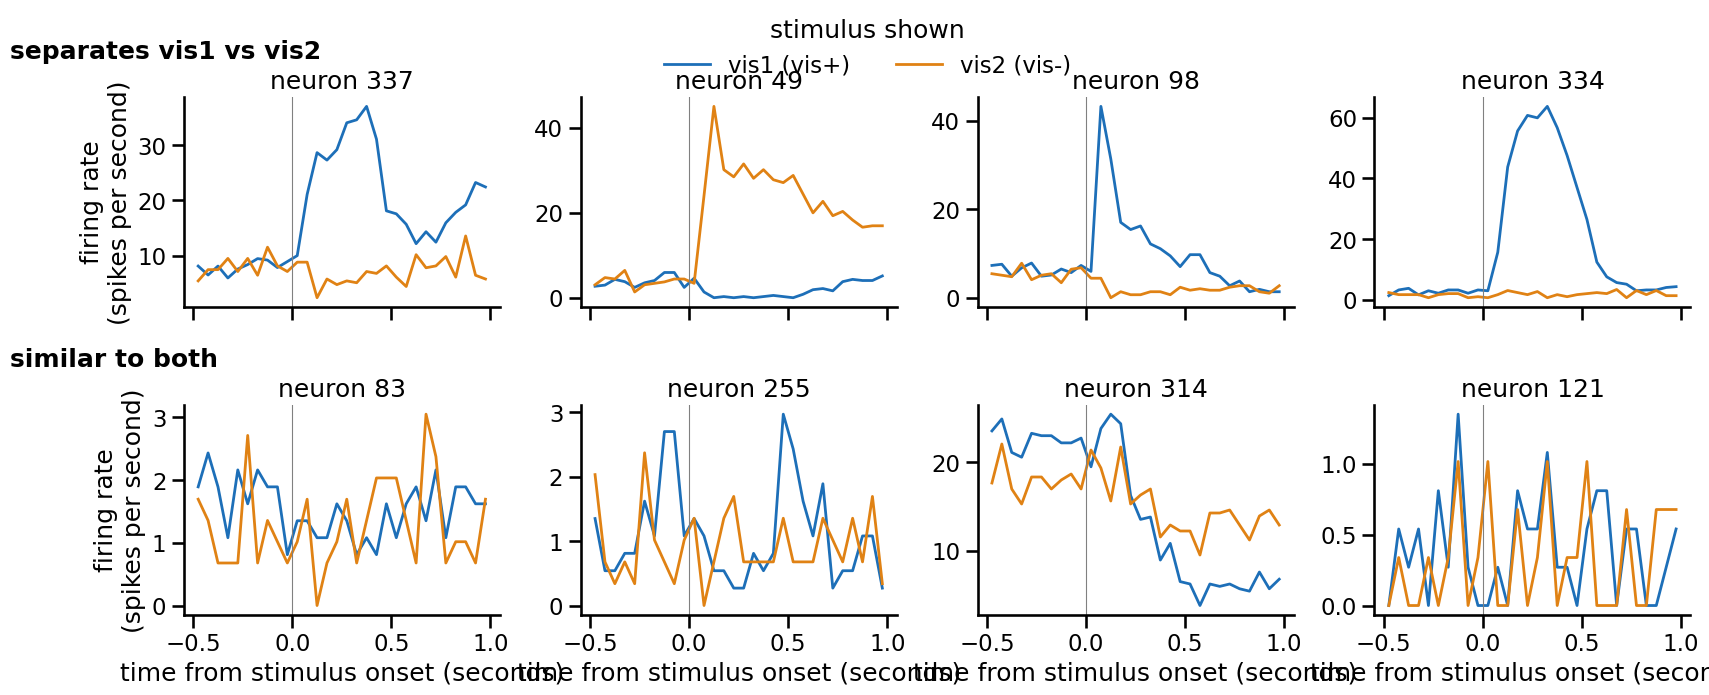

In [28]:
VIS_SELECTIVE_INDEX_LIST = [337, 49, 98, 334]
VIS_SIMILAR_INDEX_LIST   = [83, 255, 314, 121]

psth_bin_edge_array = np.arange(-0.5, 1.0 + 0.05, 0.05)
psth_bin_center_array = psth_bin_edge_array[:-1] + 0.05 / 2

vis1_stim_time_array = trials.loc[
    (trials.stim_name == 'vis1') & (trials.rewarded_modality == 'vis'),
    'stim_start_time'].values
vis2_stim_time_array = trials.loc[
    (trials.stim_name == 'vis2') & (trials.rewarded_modality == 'vis'),
    'stim_start_time'].values
print('visual-context trials: vis1 = %d, vis2 = %d'
      % (len(vis1_stim_time_array), len(vis2_stim_time_array)))


def neuron_psth(neuron_row_index, stim_time_array):
    spike_time_array = this_structure_units_table.spike_times.values[neuron_row_index]
    count_array = get_binned_triggered_spike_counts_fast(
        spike_time_array, stim_time_array, psth_bin_edge_array)
    return count_array.mean(axis=0) / 0.05


color_vis1 = '#1D6FB8'
color_vis2 = '#E08214'

fig, ax = plt.subplots(2, 4, figsize=(17, 7), sharex=True)
row_index_list = [VIS_SELECTIVE_INDEX_LIST, VIS_SIMILAR_INDEX_LIST]
row_text_list = ['separates vis1 vs vis2', 'similar to both']
for row in range(2):
    for col in range(4):
        neuron_row_index = row_index_list[row][col]
        single_ax = ax[row, col]
        single_ax.plot(psth_bin_center_array,
                       neuron_psth(neuron_row_index, vis1_stim_time_array),
                       color=color_vis1, linewidth=2, label='vis1 (vis+)')
        single_ax.plot(psth_bin_center_array,
                       neuron_psth(neuron_row_index, vis2_stim_time_array),
                       color=color_vis2, linewidth=2, label='vis2 (vis-)')
        single_ax.axvline(0, color='0.5', linewidth=0.8)
        single_ax.set_title('neuron %d' % neuron_row_index)
        sns.despine(ax=single_ax)
    ax[row, 0].set_ylabel('firing rate\n(spikes per second)')
    ax[row, 0].annotate(row_text_list[row], xy=(-0.55, 1.18),
                        xycoords='axes fraction', fontweight='bold')
for single_ax in ax[-1, :]:
    single_ax.set_xlabel('time from stimulus onset (seconds)')
handle_list, label_list = ax[0, 0].get_legend_handles_labels()
fig.legend(handle_list, label_list, title='stimulus shown',
           loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
fig.subplots_adjust(hspace=0.5, wspace=0.4)
fig.tight_layout()
plt.show()

# 2 Can we decode stimulus identity from a single neuron?

Its time to look at our first neuron from this course! (WOOT).

You are going to hear this many times over the next to weeks: In this course, we will fit many models with increaseing levels of abstraction to our data. It is always going to be tempting to jump streight into modeling, and gloss over the actual data. Don't be tempted to do this! Looking at and understanding your  data is, at the end of the day, alway more important than whatever model you might fit. Afterall, if your data are bad, so is your model.

Fortunatly, someone here has already done a good chunk of the QC on our data. So here, "data" really means the spike times for a given unit.

With this in mind, lets look at the activity of a single neuron as the mouse is presented with its stimulus. First, we need some data.

### 2.1 Rasters and PSTHs

What we what to know right now is, how does this neuron respond to a stimulus?

To answer this, we need to grab a window of time around the when the stimulus was presented. We will then look at the only the spikes that happen within this window. 

We are going to make two types of plots to visualize these data. 

+ The first we call a ** raster ** plot. Here, we will represent each spike by a dot, and each trial as a row in our plot.
+ The raster plot is useful for visualizng activity accross trials, but it can be difficult to quantify. With this in mind, we will also make a ** Peristimulus Time Histogoram ** or ** PSTH **. This is the averaged stimulus triggered average for the neuron or, equivalently, a histogram showing the average of the raster plot.

Pick one neuron, and grab the spikes in a window around every stimulus onset.

In [32]:
unit = VIS_SELECTIVE_INDEX_LIST[0]
spike_times = this_structure_units_table.spike_times.values[unit]
stim_times = trials.stim_start_time.values
print('neuron %d has %d spikes' % (unit, len(spike_times)))
print('first few stimulus onset times: %s' % np.round(stim_times[:5], 2))

neuron 337 has 68054 spikes
first few stimulus onset times: [2521.31 2526.95 2537.78 2543.78 2553.41]


Collect spikes in a window around each stimulus, aligned to onset.

In [34]:
pre_window = 0.5
post_window = 2.0
bin_size = 0.05
bins = np.arange(-pre_window, post_window + bin_size, bin_size)
bin_centers = bins[:-1] + bin_size / 2

triggered_spike_times = []
triggered_trial_index = []
for i, stim_time in enumerate(stim_times):
    mask = ((spike_times >= stim_time - pre_window) &
            (spike_times < stim_time + post_window))
    trial_spikes = spike_times[mask] - stim_time
    triggered_spike_times.append(trial_spikes)
    triggered_trial_index.append(np.ones(len(trial_spikes)) * i)
print('collected spikes around %d trials' % len(stim_times))

collected spikes around 538 trials


Flatten into vectors for plotting.

In [36]:
triggered_spike_times = np.concatenate(triggered_spike_times)
triggered_trial_index = np.concatenate(triggered_trial_index)

The raster shows every spike as a dot. The PSTH below averages them into a firing rate.

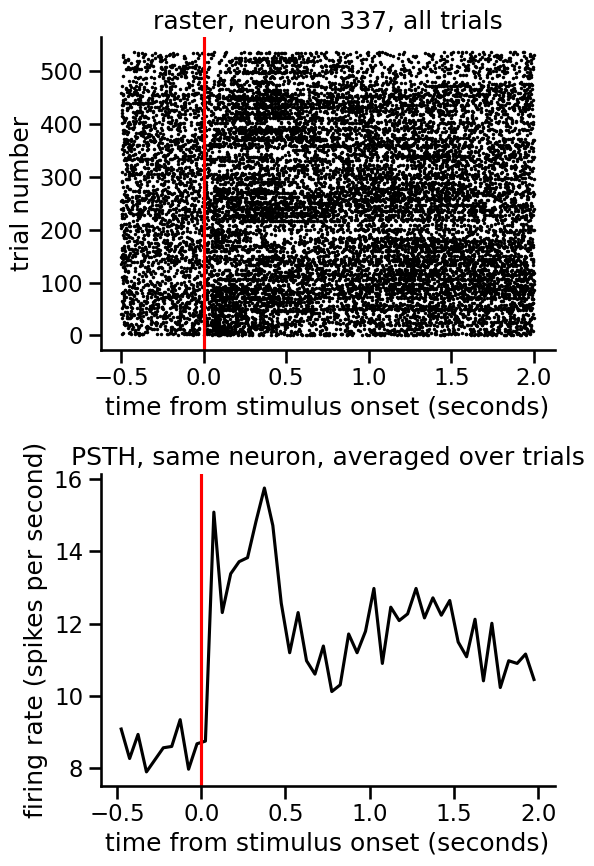

In [38]:
fig, ax = plt.subplots(nrows=2, figsize=(6, 9))
ax[0].scatter(triggered_spike_times, triggered_trial_index, s=1, c='k')
ax[0].axvline(0, c='r')
ax[0].set_xlabel('time from stimulus onset (seconds)')
ax[0].set_ylabel('trial number')
ax[0].set_title('raster, neuron %d, all trials' % unit)

count_array, _ = np.histogram(triggered_spike_times, bins=bins)
rate_array = count_array / len(stim_times) / bin_size
ax[1].plot(bin_centers, rate_array, c='k')
ax[1].axvline(0, c='r')
ax[1].set_xlabel('time from stimulus onset (seconds)')
ax[1].set_ylabel('firing rate (spikes per second)')
ax[1].set_title('PSTH, same neuron, averaged over trials')
for single_ax in ax:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

Great! We have a neuron that responds to the stimulus!

But remember our goal here- we want to know if we can decode the difference between stimuli from this neuron. With that in mind, lets try seperating out the different stimulus identities.

One handy way to do this seperation is to use numpy's ** unique ** function. Selecting return_inverse will give a easy way to sort the trial identities.

Figure out which stimulus was shown on each trial.

In [41]:
unq, stim_id = np.unique(trials.stim_name.values[triggered_trial_index.astype(int)],
                         return_inverse=True)
print('stimulus types present: %s' % unq.tolist())

stimulus types present: ['catch', 'sound1', 'sound2', 'vis1', 'vis2']


Now the raster and PSTH, colored by stimulus. This is the stimulus raster, the last look before we let a classifier take over.

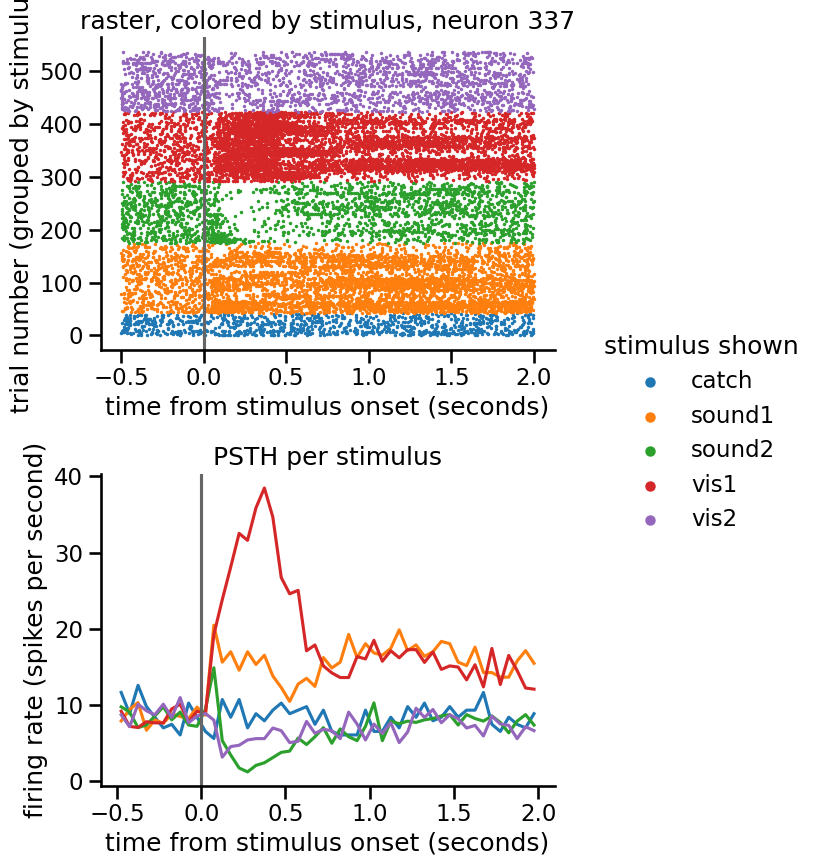

In [43]:
fig, ax = plt.subplots(nrows=2, figsize=(6, 9))
counter = 0
for stim_index in range(len(unq)):
    this_spikes = triggered_spike_times[stim_id == stim_index]
    _, this_trial_index = np.unique(triggered_trial_index[stim_id == stim_index],
                                    return_inverse=True)
    ax[0].scatter(this_spikes, counter + this_trial_index, s=1, label=unq[stim_index])
    counter += np.max(this_trial_index) + 1
    hist_array, _ = np.histogram(this_spikes, bins=bins)
    rate_array = hist_array / (np.max(this_trial_index) + 1) / bin_size
    ax[1].plot(bin_centers, rate_array, label=unq[stim_index])
ax[0].axvline(0, c='0.4')
ax[0].set_xlabel('time from stimulus onset (seconds)')
ax[0].set_ylabel('trial number (grouped by stimulus)')
ax[0].set_title('raster, colored by stimulus, neuron %d' % unit)
ax[1].axvline(0, c='0.4')
ax[1].set_xlabel('time from stimulus onset (seconds)')
ax[1].set_ylabel('firing rate (spikes per second)')
ax[1].set_title('PSTH per stimulus')
for single_ax in ax:
    sns.despine(ax=single_ax)
handle_list, label_list = ax[0].get_legend_handles_labels()
fig.legend(handle_list, label_list, title='stimulus shown',
           loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, markerscale=6)
fig.tight_layout()
plt.show()

### The linear classifier, in one picture

A **support vector machine** (SVM) draws the **decision boundary** that best
separates two classes of trials. In higher dimensions it is a **hyperplane**.
Of all separating lines, the SVM picks the one with the widest **margin**, the
biggest gap to the nearest points. Those nearest points are the **support
vectors**, and they alone pin the boundary. Move any other point and nothing
changes.

The illustration below shows the idea.

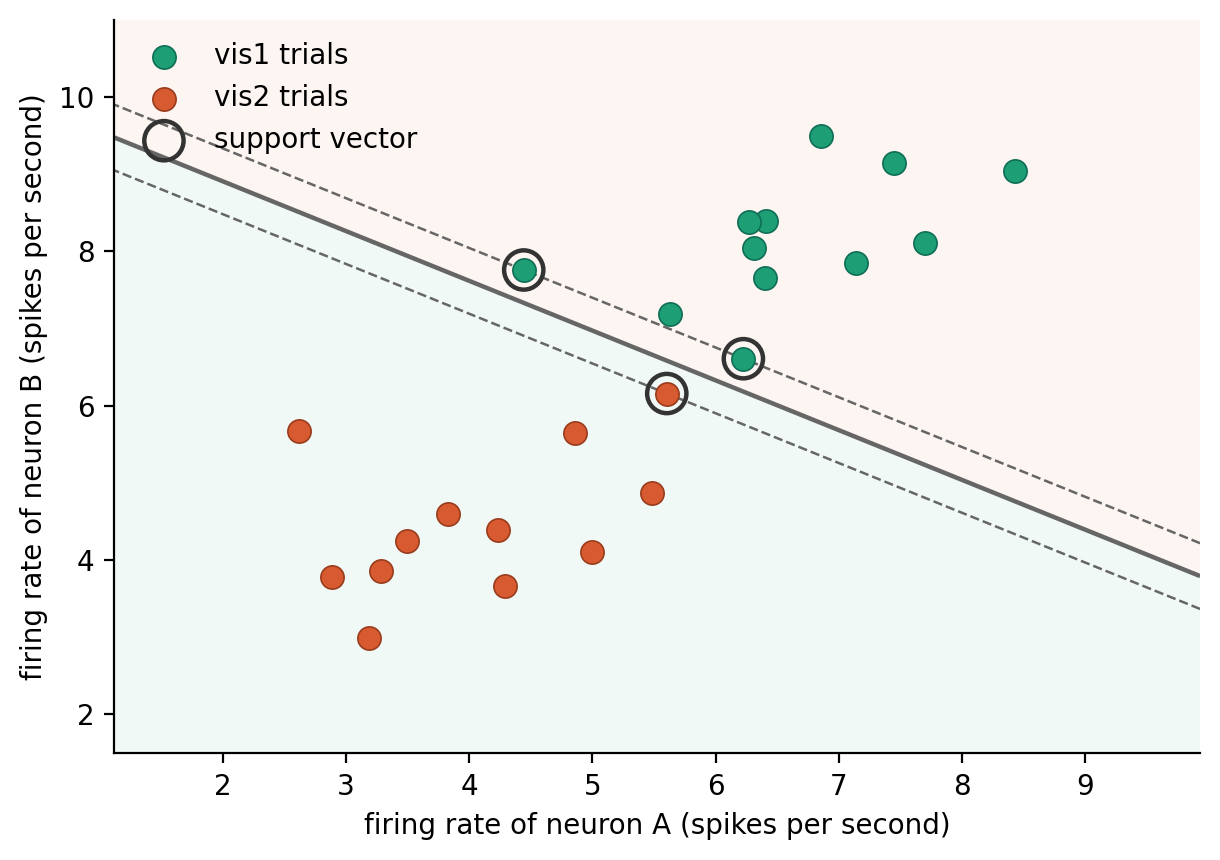

In [46]:
from IPython.display import Image, display
try:
    display(Image(filename='svm_margin_two_classes.png'))
except Exception as error:
    print('SVM illustration not found next to the notebook: %s' % error)

### 2.3 Now lets try with a neuron!!

The challenge, of course, is that our neural data is high dimensional. To keep things interpretable, lets try to small window from the overall spike train that will give us a decent chance of decoding information from this neuron.

Count each trial's spikes in the 0 to 0.5 s window, for vis1 and vis2, context fixed to visual blocks.

In [49]:
example_neuron_row_index = VIS_SELECTIVE_INDEX_LIST[0]
count_window_bin_array = np.array([0.0, 0.5])

vis1_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[example_neuron_row_index],
    vis1_stim_time_array, count_window_bin_array).ravel()
vis2_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[example_neuron_row_index],
    vis2_stim_time_array, count_window_bin_array).ravel()

single_neuron_count_array = np.concatenate([vis1_count_array, vis2_count_array])
single_neuron_label_array = np.array(
    ['vis1'] * len(vis1_count_array) + ['vis2'] * len(vis2_count_array))
print('neuron %d, %d trials total (%d vis1, %d vis2)'
      % (example_neuron_row_index, len(single_neuron_label_array),
         len(vis1_count_array), len(vis2_count_array)))

neuron 337, 133 trials total (74 vis1, 59 vis2)


The two spike-count distributions. The SVM places a single threshold between them. Histogram is the real counts, the smooth curve is a kernel density estimate.

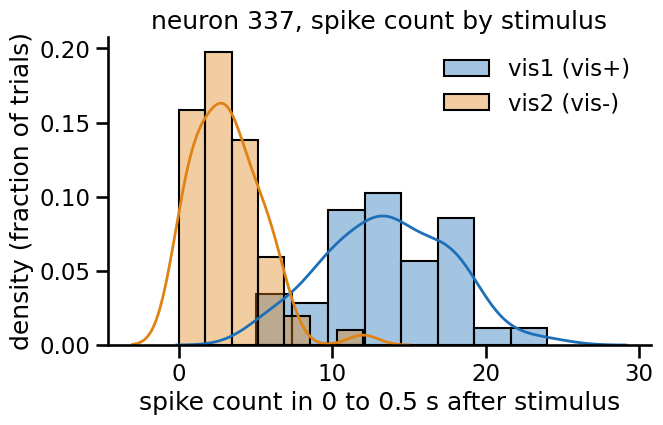

In [51]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(vis1_count_array, stat='density', color=color_vis1, alpha=0.4,
             label='vis1 (vis+)', ax=ax)
sns.histplot(vis2_count_array, stat='density', color=color_vis2, alpha=0.4,
             label='vis2 (vis-)', ax=ax)
sns.kdeplot(vis1_count_array, color=color_vis1, linewidth=2, ax=ax)
sns.kdeplot(vis2_count_array, color=color_vis2, linewidth=2, ax=ax)
ax.set_xlabel('spike count in 0 to 0.5 s after stimulus')
ax.set_ylabel('density (fraction of trials)')
ax.set_title('neuron %d, spike count by stimulus' % example_neuron_row_index)
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()

<h3> Ready? </h3>
Go ahead and fit a linear SCV to the training data!

In [53]:
x_train, x_test, y_train, y_test = train_test_split(
    single_neuron_count_array.reshape(-1, 1), single_neuron_label_array,
    random_state=0)
print('train trials: %d, test trials: %d' % (len(y_train), len(y_test)))
single_neuron_svc = LinearSVC()
single_neuron_svc.fit(x_train, y_train)
single_neuron_accuracy = single_neuron_svc.score(x_test, y_test)
print('single-neuron decoder is correct on %.0f%% of held-out trials'
      % (100 * single_neuron_accuracy))

train trials: 99, test trials: 34
single-neuron decoder is correct on 94% of held-out trials


Is this any good? When examining the answer to that question, it is probably most useful to ask, "how much better was our classifier than if we had just guessed by chance".

In cases where you have evenly distributed classes, chance estimates are easy. For example, if we just had 5 classes here, chance performance would be .2. 

However, we don't have exactly even numbers of trials: there are, for example, fewer catch trials. In cases like this, we can sometimes estimate a "chance" figure by asking, "if we shuffled trial identities, what fraction of the time would they line up with the true trial identity."

In [55]:
chance_list = []
for _ in range(1000):
    shuffled_label_array = np.random.permutation(single_neuron_label_array)
    chance_list.append(np.mean(shuffled_label_array == single_neuron_label_array))
print('shuffled chance accuracy: %.0f%%' % (100 * np.mean(chance_list)))

shuffled chance accuracy: 51%


It is worth saying that, because we have more than one class, we can dig a little deeper into our prediction.

Specifically, when we guess incorrectly, miss-classifications often have structure to them. A confusion matrix is a useful tool to understand mistakes a classifier makes. Here we plot, given a "true" class, what was the distribution of predictions made by our classifier.

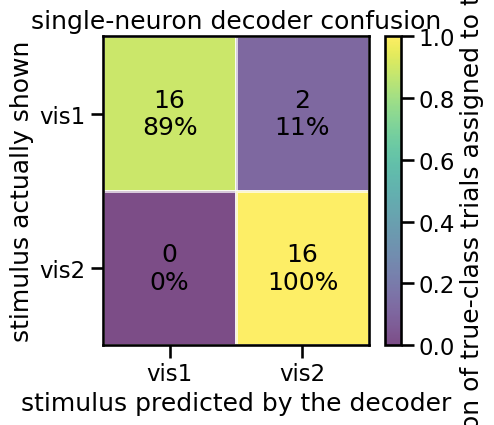

In [57]:
y_prediction = single_neuron_svc.predict(x_test)
stim_name_array = np.array(['vis1', 'vis2'])


def plot_confusion(y_true, y_pred, label_array, title):
    count_array = confusion_matrix(y_true, y_pred, labels=label_array)
    fraction_array = count_array / count_array.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    mesh = ax.pcolormesh(fraction_array, cmap='viridis', alpha=0.7,
                         edgecolor='white', linewidth=2)
    for r in range(len(label_array)):
        for c in range(len(label_array)):
            ax.text(c + 0.5, r + 0.5, '%d\n%.0f%%'
                    % (count_array[r, c], 100 * fraction_array[r, c]),
                    ha='center', va='center', color='black')
    ax.set_xticks(np.arange(len(label_array)) + 0.5)
    ax.set_yticks(np.arange(len(label_array)) + 0.5)
    ax.set_xticklabels(label_array)
    ax.set_yticklabels(label_array)
    ax.invert_yaxis()
    ax.set_xlabel('stimulus predicted by the decoder')
    ax.set_ylabel('stimulus actually shown')
    ax.set_title(title)
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label('fraction of true-class trials assigned to this class')
    fig.tight_layout()
    plt.show()


plot_confusion(y_test, y_prediction, stim_name_array, 'single-neuron decoder confusion')

One neuron already beats a coin flip. But we recorded a whole population, so lets use all of MOs at once.

# 3.0 Now for a neural population.

While the mathematical formalizim is useful to understand what our chosen neuron is doing here, if we are being honest its probably overkill for understanding this single neurons activity. There are, in fact, whole classes of regression models that might be better suited for asking what information a neuron encodes. 

Why, then, have we spent so much time on this example? Decoding gives us a mathematical way to look at what information we can extract from a neural population. As this population becomes larger, however, it can become increasingly difficult to visualize and intuite what our decoder is doing under the hood. Starting with this one-dimension example will help with inuition as we move to this harder case.

To start, lets use decoding to take a hard look at the timescale of MOs' encoding of stimulus identity. 

Doing this is going to require a fair bit of data wrangling. Just as before, we needed to get the number of spikes per trial. But if we are looking over time and over neurons, we need to get the number of spikes for each neuron on each trial. 

Here is one way to do this, though you will notice that it is a little on the slow side.

Each **row is a trial (a sample)**, each **column is a neuron (a feature)**,
and the value is that neuron's **spike count** in the 0 to 0.5 s window. This is a
count, not a rate.

In [62]:
decode_bin_edge_array = np.arange(-0.3, 2.0, 0.1)
decode_trial_mask = (trials.stim_name.isin(['vis1', 'vis2']) &
                     (trials.rewarded_modality == 'vis'))
decode_stim_time_array = trials.loc[decode_trial_mask, 'stim_start_time'].values
decode_label_array = trials.loc[decode_trial_mask, 'stim_name'].values
print('%d visual-context trials go into the decoder' % len(decode_label_array))

n_neurons = len(this_structure_units_table)
population_tensor = np.zeros((n_neurons, len(decode_stim_time_array),
                              len(decode_bin_edge_array) - 1))
for neuron_row_index in range(n_neurons):
    population_tensor[neuron_row_index] = get_binned_triggered_spike_counts_fast(
        this_structure_units_table.spike_times.values[neuron_row_index],
        decode_stim_time_array, decode_bin_edge_array)

window_bin_slice = slice(3, 9)   # 0 to 0.5 s after onset
population_count_array = np.sum(population_tensor[:, :, window_bin_slice], axis=2).T
print('input matrix shape (trials, neurons) = %s' % (population_count_array.shape,))
assert population_count_array.shape[0] == len(decode_label_array), \
    'row count (%d) must equal number of trials (%d)' % (
        population_count_array.shape[0], len(decode_label_array))

133 visual-context trials go into the decoder
input matrix shape (trials, neurons) = (133, 382)


This is exactly what the SVM sees. No single column separates the stimuli
alone, but the pattern across columns does.

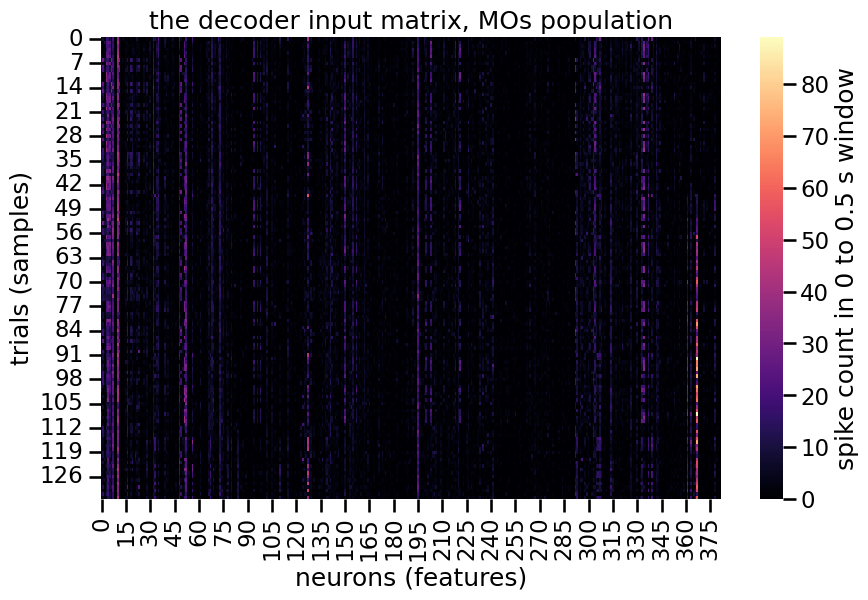

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(population_count_array, cmap='magma', ax=ax,
            cbar_kws={'label': 'spike count in 0 to 0.5 s window'})
ax.set_xlabel('neurons (features)')
ax.set_ylabel('trials (samples)')
ax.set_title('the decoder input matrix, MOs population')
plt.show()

Fit the population decoder, same recipe as one neuron with more features.

In [66]:
x_train, x_test, y_train, y_test = train_test_split(
    population_count_array, decode_label_array, random_state=0)
population_svc = LinearSVC(max_iter=5000)
population_svc.fit(x_train, y_train)
population_accuracy = population_svc.score(x_test, y_test)
print('population decoder is correct on %.0f%% of held-out trials'
      % (100 * population_accuracy))

population decoder is correct on 100% of held-out trials


The confusion matrix for the population decoder.

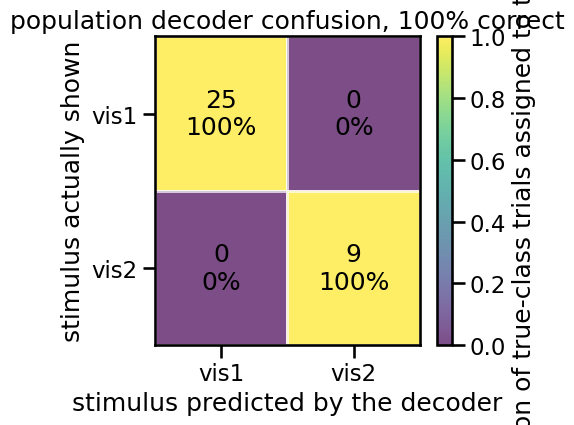

In [68]:
plot_confusion(y_test, population_svc.predict(x_test), stim_name_array,
               'population decoder confusion, %.0f%% correct'
               % (100 * population_accuracy))

Impressive, right?

What this means is that we can, using all of our MOs neurons, very reliably decode stimulus identity. This is, in and of itself, pretty exciting. But we can use our new decoding technique to dig deeper into the behavior of the neural population within our chosen time window.

To do this, we can loop through a fit a model to each time bin. Once we have that model, we can compute the score for each model using both the training and testing partitions in our dataset.

We fit a separate decoder for each time bin. Each point is its own decoder,
so we plot markers, not a line, they are not one continuous curve. Gray dots are
the five cross-validation folds, colored dots the median.

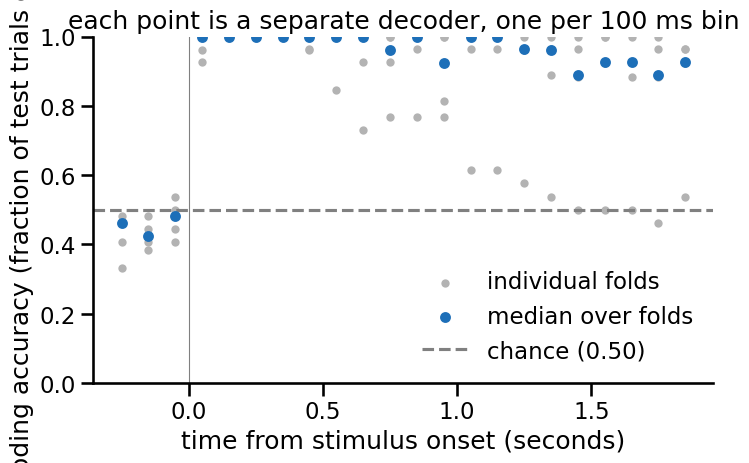

In [71]:
bin_center_array = (decode_bin_edge_array[:-1]
                    + np.median(np.diff(decode_bin_edge_array)) / 2)
n_fold = 5
per_bin_score_array = np.empty((len(decode_bin_edge_array) - 1, n_fold))
for bin_index in range(len(decode_bin_edge_array) - 1):
    single_bin_feature_array = population_tensor[:, :, bin_index].T
    per_bin_score_array[bin_index] = cross_validate(
        LinearSVC(max_iter=5000), single_bin_feature_array,
        decode_label_array, cv=n_fold)['test_score']
median_score_array = np.median(per_bin_score_array, axis=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
for fold_index in range(n_fold):
    ax.scatter(bin_center_array, per_bin_score_array[:, fold_index],
               color='0.7', s=20, zorder=2,
               label='individual folds' if fold_index == 0 else None)
ax.scatter(bin_center_array, median_score_array, color='#1D6FB8', s=40,
           zorder=3, label='median over folds')
ax.axhline(0.5, linestyle='--', color='0.5', label='chance (0.50)')
ax.axvline(0, color='0.5', linewidth=0.8)
ax.set_ylim(0, 1)
ax.set_xlabel('time from stimulus onset (seconds)')
ax.set_ylabel('decoding accuracy (fraction of test trials correct)')
ax.set_title('each point is a separate decoder, one per 100 ms bin')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()

## 4. Your turn, decode the two sounds

The task also has two auditory stimuli, **sound1** (aud+) and **sound2** (aud-).

**Exercise.** Copy the population recipe from section 3, but decode sound1 vs
sound2, with context fixed to auditory blocks.

1. Trial mask: `trials.stim_name.isin(['sound1', 'sound2'])` and
   `trials.rewarded_modality == 'aud'`.
2. Reuse `get_binned_triggered_spike_counts_fast`.
3. Print the held-out accuracy with a labeled `print`.

Guess first: does MOs decode sounds as well as it decodes the visual stimuli?

Write your solution in the cell below.

In [74]:
# your code here

## 5. Why is the decoder ever wrong? Context

Our vis1 vs vis2 decoder is good but not perfect. One suspect for the mistakes is
**context**, which modality is currently rewarded.

### 5.1 Same stimulus, split by context

First, look again with your eyes. Here are three (randomly chosen, hardcoded)
example neurons. For each, we take **vis1 trials only** and split them by context:
vis1 shown in a visual block vs vis1 shown in an auditory block. Same stimulus,
different context. Try changing the neuron indices to explore others.

vis1 trials: 74 in visual context, 57 in auditory context


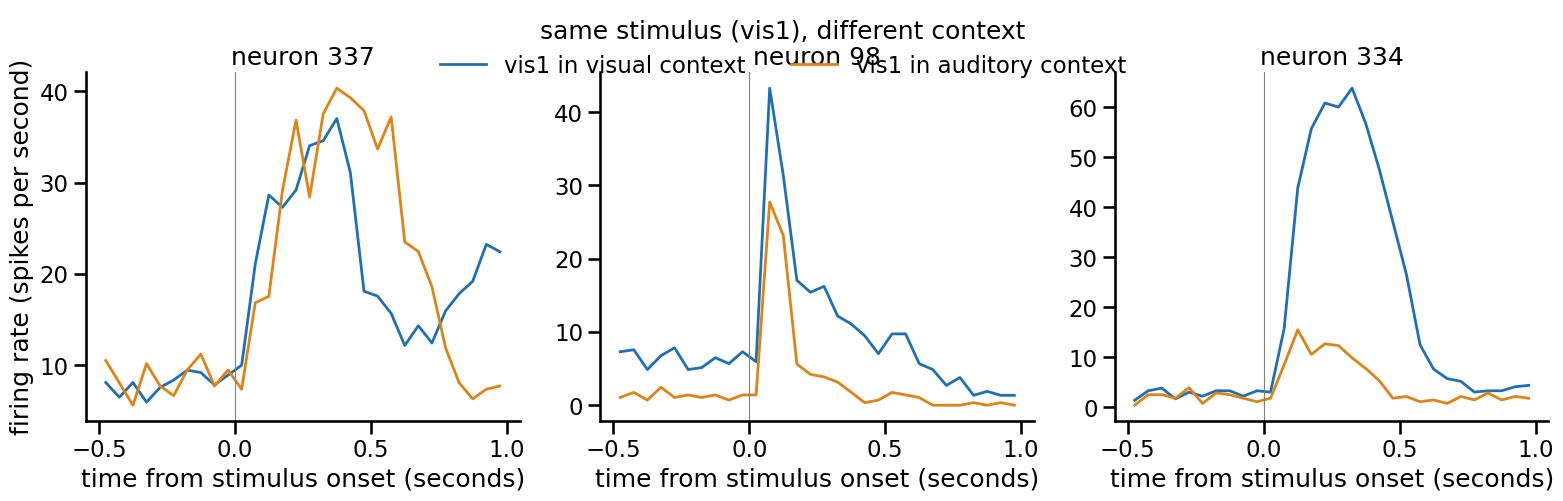

In [77]:
# three 'random' example neurons (hardcoded so the class sees the same ones).
# try changing these!
RANDOM_EXAMPLE_INDEX_LIST = [337, 98, 334]

color_context_vis = '#1D6FB8'   # visual context
color_context_aud = '#E08214'   # auditory context

vis1_vis_time_array = trials.loc[
    (trials.stim_name == 'vis1') & (trials.rewarded_modality == 'vis'),
    'stim_start_time'].values
vis1_aud_time_array = trials.loc[
    (trials.stim_name == 'vis1') & (trials.rewarded_modality == 'aud'),
    'stim_start_time'].values
print('vis1 trials: %d in visual context, %d in auditory context'
      % (len(vis1_vis_time_array), len(vis1_aud_time_array)))

fig, ax = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
for panel_index, neuron_row_index in enumerate(RANDOM_EXAMPLE_INDEX_LIST):
    single_ax = ax[panel_index]
    single_ax.plot(psth_bin_center_array,
                   neuron_psth(neuron_row_index, vis1_vis_time_array),
                   color=color_context_vis, linewidth=2, label='vis1 in visual context')
    single_ax.plot(psth_bin_center_array,
                   neuron_psth(neuron_row_index, vis1_aud_time_array),
                   color=color_context_aud, linewidth=2, label='vis1 in auditory context')
    single_ax.axvline(0, color='0.5', linewidth=0.8)
    single_ax.set_title('neuron %d' % neuron_row_index)
    single_ax.set_xlabel('time from stimulus onset (seconds)')
    sns.despine(ax=single_ax)
ax[0].set_ylabel('firing rate (spikes per second)')
handle_list, label_list = ax[0].get_legend_handles_labels()
fig.legend(handle_list, label_list, title='same stimulus (vis1), different context',
           loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=2, frameon=False)
fig.tight_layout()
plt.show()

### 5.2 Decode vis1 vs vis2 pooling both contexts

Now decode the two stimuli, but let the trials come from both contexts. Each
stimulus now carries extra, context-driven variability.

In [79]:
pooled_trial_mask = trials.stim_name.isin(['vis1', 'vis2'])
pooled_stim_time_array = trials.loc[pooled_trial_mask, 'stim_start_time'].values
pooled_label_array = trials.loc[pooled_trial_mask, 'stim_name'].values
pooled_context_array = trials.loc[pooled_trial_mask, 'rewarded_modality'].values
print('pooled trials: %d (both contexts)' % len(pooled_label_array))

pooled_tensor = np.zeros((n_neurons, len(pooled_stim_time_array),
                          len(decode_bin_edge_array) - 1))
for neuron_row_index in range(n_neurons):
    pooled_tensor[neuron_row_index] = get_binned_triggered_spike_counts_fast(
        this_structure_units_table.spike_times.values[neuron_row_index],
        pooled_stim_time_array, decode_bin_edge_array)
pooled_count_array = np.sum(pooled_tensor[:, :, window_bin_slice], axis=2).T

x_train, x_test, y_train, y_test, context_train, context_test = train_test_split(
    pooled_count_array, pooled_label_array, pooled_context_array, random_state=0)
pooled_svc = LinearSVC(max_iter=5000)
pooled_svc.fit(x_train, y_train)
pooled_accuracy = pooled_svc.score(x_test, y_test)
print('pooled-context decoder is correct on %.0f%% of held-out trials'
      % (100 * pooled_accuracy))

pooled trials: 246 (both contexts)
pooled-context decoder is correct on 98% of held-out trials


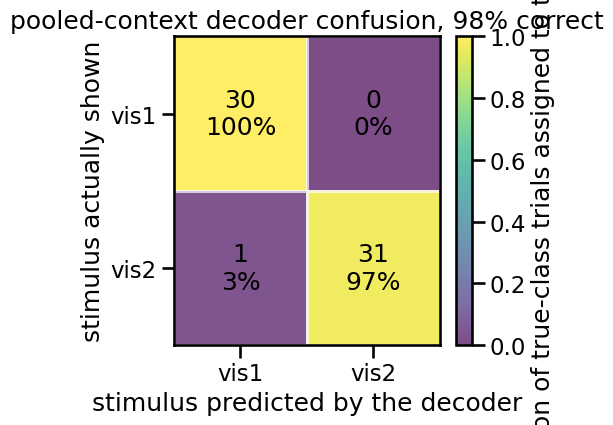

In [137]:
plot_confusion(y_test, pooled_svc.predict(x_test), stim_name_array,
               'pooled-context decoder confusion, %.0f%% correct'
               % (100 * pooled_accuracy))

### 5.3 Where do the mistakes sit?

Color the held-out trials by the context they came from, split correct vs mistake.
If context is the culprit, the errors will not be spread evenly.

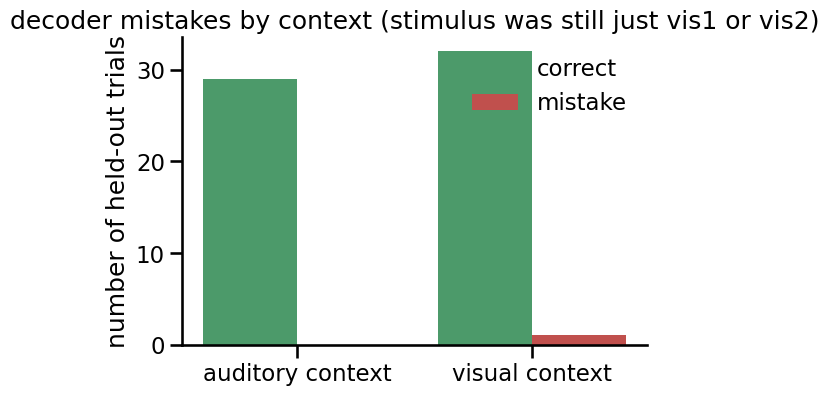

In [81]:
y_test_prediction = pooled_svc.predict(x_test)
is_error_array = y_test_prediction != y_test
context_name_array = np.array(['aud', 'vis'])
correct_count_list = [np.sum(context_test[~is_error_array] == c) for c in context_name_array]
error_count_list = [np.sum(context_test[is_error_array] == c) for c in context_name_array]

fig, ax = plt.subplots(figsize=(6, 4))
x_pos_array = np.arange(len(context_name_array))
ax.bar(x_pos_array - 0.2, correct_count_list, width=0.4, color='#4C9A6A', label='correct')
ax.bar(x_pos_array + 0.2, error_count_list, width=0.4, color='#C0504D', label='mistake')
ax.set_xticks(x_pos_array)
ax.set_xticklabels(['auditory context', 'visual context'])
ax.set_ylabel('number of held-out trials')
ax.set_title('decoder mistakes by context (stimulus was still just vis1 or vis2)')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()

### 5.4 How can we improve it? Fix the context

Hold context fixed to visual blocks (the section 3 decode) and compare against the
pooled version.

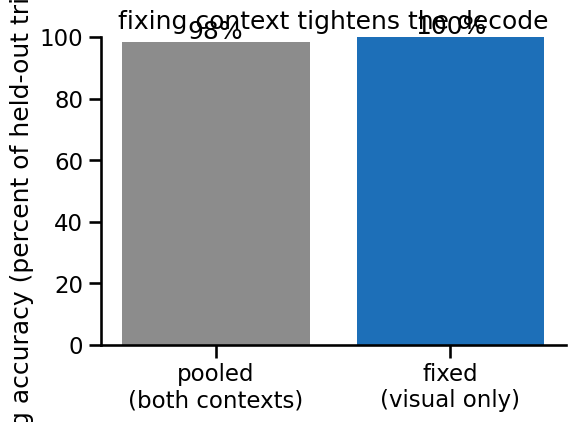

In [83]:
fig, ax = plt.subplots(figsize=(6, 4))
bar_label_list = ['pooled\n(both contexts)', 'fixed\n(visual only)']
bar_value_list = [100 * pooled_accuracy, 100 * population_accuracy]
ax.bar(bar_label_list, bar_value_list, color=['#8C8C8C', '#1D6FB8'])
for x_pos, value in enumerate(bar_value_list):
    ax.text(x_pos, value + 1, '%.0f%%' % value, ha='center')
ax.set_ylabel('decoding accuracy (percent of held-out trials correct)')
ax.set_ylim(0, 100)
ax.set_title('fixing context tightens the decode')
sns.despine(ax=ax)
plt.show()

### 5.5 Thinking question

Fixing context improved the decoder. **Why?**

The stimulus was the same either way, vis1 or vis2. What did pooling the two
contexts add that made the two stimulus clouds harder to separate? And what does
that tell you about what MOs represents, beyond the stimulus itself?

## 6. Which neurons carry the decode?

The fitted SVM gives every neuron a weight. Usually a few neurons do most of the
work.

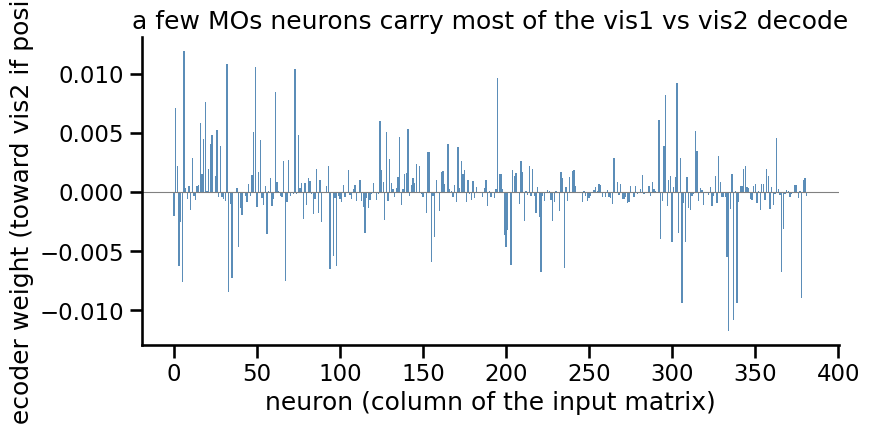

In [86]:
weight_array = population_svc.coef_.ravel()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(np.arange(len(weight_array)), weight_array, color='#5B8DB8')
ax.axhline(0, color='0.5', linewidth=0.8)
ax.set_xlabel('neuron (column of the input matrix)')
ax.set_ylabel('decoder weight (toward vis2 if positive)')
ax.set_title('a few MOs neurons carry most of the vis1 vs vis2 decode')
sns.despine(ax=ax)
plt.show()

# BONUS

## Train on one context, test on the other
Here is the deeper question the original notebook ended on. If MOs really carries a
stimulus code, a decoder trained in one context should still work in the other.

We train the vis1 vs vis2 decoder on **auditory-context** trials, then test it on
**visual-context** trials, and vice versa. If accuracy holds up, the stimulus code
generalizes across context. If it drops, context is entangled with the stimulus
representation.

Build context-specific matrices, then cross-decode.

In [89]:
def population_matrix_for_mask(trial_mask):
    stim_time_array = trials.loc[trial_mask, 'stim_start_time'].values
    label_array = trials.loc[trial_mask, 'stim_name'].values
    tensor = np.zeros((n_neurons, len(stim_time_array), len(decode_bin_edge_array) - 1))
    for neuron_row_index in range(n_neurons):
        tensor[neuron_row_index] = get_binned_triggered_spike_counts_fast(
            this_structure_units_table.spike_times.values[neuron_row_index],
            stim_time_array, decode_bin_edge_array)
    count_array = np.sum(tensor[:, :, window_bin_slice], axis=2).T
    return count_array, label_array


vis_mask = trials.stim_name.isin(['vis1', 'vis2']) & (trials.rewarded_modality == 'vis')
aud_mask = trials.stim_name.isin(['vis1', 'vis2']) & (trials.rewarded_modality == 'aud')

x_vis_context, y_vis_context = population_matrix_for_mask(vis_mask)
x_aud_context, y_aud_context = population_matrix_for_mask(aud_mask)

# train on auditory context, test on visual context
svc_train_aud = LinearSVC(max_iter=5000).fit(x_aud_context, y_aud_context)
acc_aud_to_vis = svc_train_aud.score(x_vis_context, y_vis_context)

# train on visual context, test on auditory context
svc_train_vis = LinearSVC(max_iter=5000).fit(x_vis_context, y_vis_context)
acc_vis_to_aud = svc_train_vis.score(x_aud_context, y_aud_context)

print('train auditory context, test visual context: %.0f%% correct'
      % (100 * acc_aud_to_vis))
print('train visual context, test auditory context: %.0f%% correct'
      % (100 * acc_vis_to_aud))

train auditory context, test visual context: 100% correct
train visual context, test auditory context: 100% correct


Compare the cross-context accuracies to the within-context decoder from section 3.

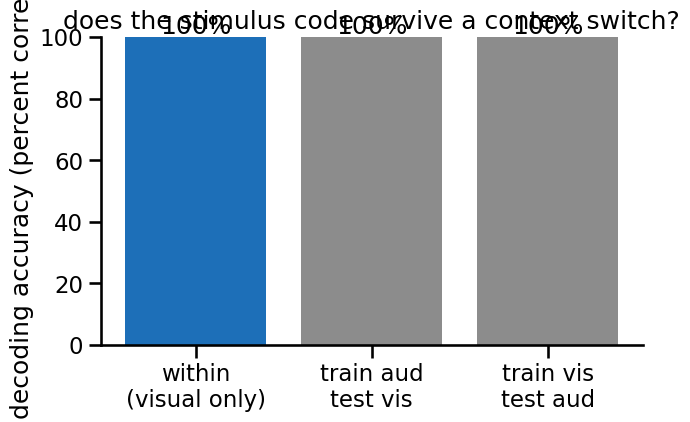

In [91]:
fig, ax = plt.subplots(figsize=(7, 4))
bar_label_list = ['within\n(visual only)', 'train aud\ntest vis', 'train vis\ntest aud']
bar_value_list = [100 * population_accuracy, 100 * acc_aud_to_vis, 100 * acc_vis_to_aud]
ax.bar(bar_label_list, bar_value_list, color=['#1D6FB8', '#8C8C8C', '#8C8C8C'])
for x_pos, value in enumerate(bar_value_list):
    ax.text(x_pos, value + 1, '%.0f%%' % value, ha='center')
ax.set_ylabel('decoding accuracy (percent correct)')
ax.set_ylim(0, 100)
ax.set_title('does the stimulus code survive a context switch?')
sns.despine(ax=ax)
plt.show()

### A reusable PSTH helper

A compact PSTH function you can reuse in your own analyses.

In [93]:
def make_psth(spike_times, stim_times, pre_window=0.5, post_window=1.0, bin_size=0.05):
    """
    Generate a Peri-Stimulus Time Histogram (PSTH).
    
    Parameters:
    - spike_times: array-like, timestamps of all spikes (in seconds)
    - stim_times: array-like, timestamps of stimulus onsets (in seconds)
    - pre_window: float, time before stimulus to include in PSTH (seconds)
    - post_window: float, time after stimulus to include in PSTH (seconds)
    - bin_size: float, width of each time bin (seconds)
    
    Returns:
    - firing_rates: 2D numpy array of firing rates (trials x bins)
    - bin_centers: 1D numpy array of bin center times (relative to stimulus onset)
    """

    # Ensure inputs are numpy arrays 
    spike_times = np.array(spike_times)
    stim_times = np.array(stim_times)
    
    # Define bin edges from -pre_window to +post_window
    bins = np.arange(-pre_window, post_window + bin_size, bin_size)
    
    # Compute centers of bins (for plotting)
    bin_centers = bins[:-1] + bin_size / 2
    
    # Initialize a matrix to hold spike counts: rows = trials, columns = bins
    all_counts = np.zeros((len(stim_times), len(bins) - 1))
    
    # Loop through each stimulus time to compute trial-specific spike counts
    for i, stim_time in enumerate(stim_times):
        # Select spikes that fall within the time window around this stimulus
        mask = ((spike_times >= stim_time - pre_window) & 
                (spike_times < stim_time + post_window))
        
        # Align spike times to stimulus onset (0 = stimulus)
        trial_spikes = spike_times[mask] - stim_time
        
        # Bin the aligned spikes and count how many fall into each bin
        counts, _ = np.histogram(trial_spikes, bins=bins)
        
        # Store the result in the i-th row (trial)
        all_counts[i, :] = counts
    
    # Convert spike counts to firing rates (spikes per second)
    firing_rates = all_counts / bin_size
    
    # Return firing rates (trials x bins) and bin center positions
    return firing_rates, bin_centers

## Recap

1. Single neurons carry some stimulus information, visible by eye.
2. An SVM finds the widest-margin boundary between two classes of trials.
3. The population decodes far better than any single neuron.
4. The decoder's mistakes are not random. Context leaks into the neural response,
   and fixing context makes the stimulus easier to read out.

MOs is not only relaying the stimulus, it is also carrying context. What the brain
does with that is the interesting part.